In this notebook, we compared estimation results of setup3 using OXTS forward velocity and computed linear velocity.
The purpose of the experiment is to investigate if velocity motion model still retains its estimation accuracy when using the computed linear velocity instead of the forward velocity obtained from OXTS INS.

In [1]:
import os
import sys
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.append('/app/src')
from data_loader import DataLoader
from configs.configs import (
    SetupEnum, FilterEnum, NoiseTypeEnum, MeasurementDataEnum
)
from kalman_filters import (
    ExtendedKalmanFilter,
    UnscentedKalmanFilter,
    EnsembleKalmanFilter,
    ParticleFilter, ResamplingAlgorithms,
    CubatureKalmanFilter,
)
from utils.error_report import get_error_report, print_error_report


%matplotlib inline
np.random.seed(777)

In [2]:
class CustomDataLoader(DataLoader):

    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_vo_measurement_by_index_custom(self, index, measurement_type=MeasurementDataEnum.ALL_DATA):
        """return VO data
        Args:
            measurement_type (_type_, optional): _description_. Defaults to MeasurementDataEnum.ALL_DATA.

        Returns:
            vo_data: vo data numpy array
            vo_error_cov_matrix: vo error covariance matrix when measurement_type=COVARIANCE
        """
        vo_data = self.VO_measurements_with_noise[index].reshape(-1, 1)
        
        if measurement_type is MeasurementDataEnum.ALL_DATA:
            return (vo_data, None)
        elif measurement_type is MeasurementDataEnum.DROPOUT:
            if index not in self.vo_indices:
                return (None, None)
            return (vo_data, None)
        elif measurement_type is MeasurementDataEnum.COVARIANCE:
            error = self.VO_noise_std if index in self.vo_indices else self.VO_noise_std_uncertain
            q = np.repeat(error ** 2, self.dimension)
            return (vo_data, np.eye(self.dimension) * q)
        
        return (None, None)

    def get_prev_vo_measurement_from_current_index(self, index, measurement_type=MeasurementDataEnum.ALL_DATA):
        """ return previous VO data considering dropout 
        """
        index = index - 1
        if measurement_type is not MeasurementDataEnum.DROPOUT:
            return self.VO_measurements_with_noise[index].reshape(-1, 1)
            
        while index not in self.vo_indices and index >= 0:
            index -= 1
            
        return self.VO_measurements_with_noise[index].reshape(-1, 1)

Data size: 1591
Shape:
GPS: (1591, 3)
VO: (1591, 3)
IMU: (1591, 6)
INS angle: (1591, 3)
INS velocity: (1591, 3)
Add noise to GPS data
Adding noise to VO data
Adding noise to IMU sensor data
Adding noise to linear acceleration
Adding noise to angular velocity
Adding noise to INS sensor data
Adding noise to linear velocity data
Adding noise to angle data
Data sampling is set to normal mode.


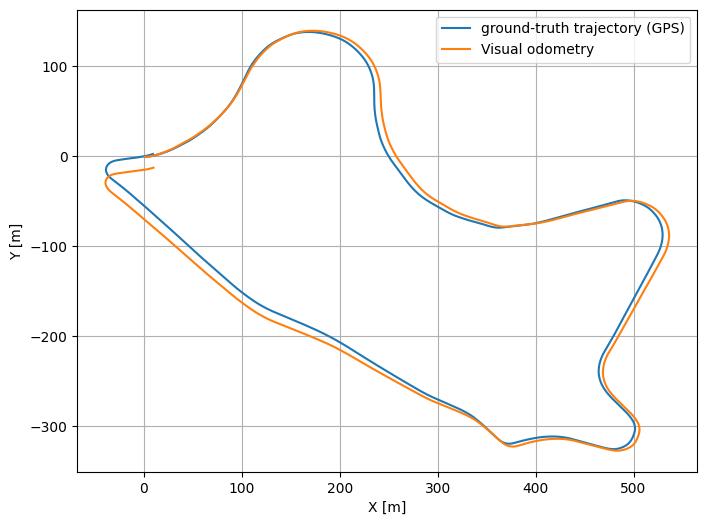

In [3]:
root_path = '../../../../'
kitti_root_dir = os.path.join(root_path, "data")
noise_vector_dir = os.path.join(root_path, "exports/_noise_optimizations/noise_vectors")
kitti_date = '2011_09_30'
kitti_drive = '0033'

# Dropping all measurement data results in IMU-only estimation
data = CustomDataLoader(
    sequence_nr=kitti_drive, 
    kitti_root_dir=kitti_root_dir, 
    noise_vector_dir=noise_vector_dir,
    vo_dropout_ratio=0.3, 
    gps_dropout_ratio=0.3,
    visualize_data=True
)

In [4]:
class InternalExtendedKalmanFilter(ExtendedKalmanFilter):

    t_last = 0
    
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _time_update_step(self, data, t_idx, dt, Q):
        ax, ay, az = data.IMU_acc_with_noise_original[t_idx]
        wx, wy, wz = data.IMU_angular_velocity_with_noise_original[t_idx]
        u = np.array([
            ax,
            ay,
            az,
            wx,
            wy,
            wz
        ])
        self.predict_setup1_2(u=u, dt=dt, Q=Q)

    def _measurement_update_step(self, data, t_idx, t, R_vo, measurement_type):
        # z_vo, _R_vo = data.get_vo_measurement_by_index_custom(index=t_idx)
        # z_vo_prev, _ = data.get_vo_measurement_by_index_custom(index=t_idx-1)
        
        z_vo, _R_vo = data.get_vo_measurement_by_index_custom(index=t_idx)
        if measurement_type is MeasurementDataEnum.COVARIANCE:
            R_vo = _R_vo

        if z_vo is not None:
            dt = t - self.t_last
            z_vo_prev = data.get_prev_vo_measurement_from_current_index(index=t_idx)
            z = np.concatenate([
                z_vo,
                (z_vo-z_vo_prev) / dt,
            ]) # px, py, pz, vx, vy, vz
            
            self.update(z=z, R=R_vo)
            self.t_last = t

    def get_forward_velocity(self):
        return np.linalg.norm(self.x[3:6])

In [5]:
class UKF_wrapper(UnscentedKalmanFilter):

    omit_gps = True # Works as Setup1 but using velocity motion model
    ekf = None
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def omit_gps_data(self, omit_gps=True):
        self.omit_gps = omit_gps

    def _init_ekf(self, data):
        x, P, _, q, _, _ = data.get_initial_data(
            setup=SetupEnum.SETUP_1, 
            filter_type=FilterEnum.EKF,
            noise_type=NoiseTypeEnum.DEFAULT
        )
        H = np.eye(10)[:6] # for px, py, pz, vx, vy, vz
        r_vo = np.ones(6)
        self.ekf = InternalExtendedKalmanFilter(
            x=x.copy(), 
            P=P.copy(), 
            H=H.copy(),
            q=q,
            r_vo=r_vo,
            r_gps=np.zeros(1),
            setup=SetupEnum.SETUP_1
        ) 

    def _time_update_step(self, data, t_idx, dt, Q):
        vf = self.ekf.get_forward_velocity()
        u = np.array([
            vf,
            data.IMU_angular_velocity_with_noise[t_idx, 2]
        ])
        self.predict_setup3(u=u, dt=dt, Q=Q)
        
    def _measurement_update_step(self, data, t_idx, R_vo, R_gps, measurement_type):
        z_vo, _R_vo = data.get_vo_measurement_by_index(
            index=t_idx, 
            measurement_type=measurement_type)
        z_gps, _R_gps = data.get_gps_measurement_by_index(
            index=t_idx, 
            setup=self.setup, 
            measurement_type=measurement_type)
        
        if measurement_type is MeasurementDataEnum.COVARIANCE:
            R_vo = _R_vo
            R_gps = _R_gps
        
        if z_vo is not None:
            self.update(z=z_vo, R=R_vo)
        
        if z_gps is not None and not self.omit_gps:
            self.update(z=z_gps, R=R_gps)
 
    def run(self, 
            data,
            measurement_type=MeasurementDataEnum.ALL_DATA, 
            debug_mode=False,
            show_graph=False):
        
        # initialize EKF
        self._init_ekf(data)
        
        # measurement noise
        R_vo = self.R_vo
        R_gps = self.R_gps
        # process noise
        Q = self.Q

        mu_x = [self.x[0, 0],]
        mu_y = [self.x[1, 0],]
        mu_z = [self.x[2, 0],]

        t_last = 0.
        if debug_mode is True:
            print("[UKF] start.")
        for t_idx in tqdm(range(1, data.N), disable=not debug_mode):
            t = data.ts[t_idx]
            dt = t - t_last

            # prediction step(time update)
            self._time_update_step(data, t_idx, dt, Q)
            self.ekf._time_update_step(data, t_idx, dt, self.ekf.Q)

            x_hat = self.x.copy()
            mu_x.append(x_hat[0, 0])
            mu_y.append(x_hat[1, 0])
            mu_z.append(x_hat[2, 0])

            # correction step(measurement update)
            self._measurement_update_step(data, t_idx, R_vo, R_gps, measurement_type)
            self.ekf._measurement_update_step(data, t_idx, t, self.ekf.R_vo, measurement_type)

            t_last = t
            
        error = \
            get_error_report(
                    data.GPS_measurements_in_meter.T[:2, :len(mu_x)], 
                    np.array([mu_x, mu_y]))\
            if self.H.shape[0] == 2 else\
            get_error_report(
                data.GPS_measurements_in_meter.T[:3, :len(mu_x)], 
                np.array([mu_x, mu_y, mu_z])) 
            
        if debug_mode:
            print_error_report(error, f"[UKF] Error report for {SetupEnum.get_name(self.setup)}")

        if show_graph is True:
            fig, ax1 = plt.subplots(1, 1, figsize=(12, 9))
            xs, ys, _ = data.GPS_measurements_in_meter.T
            ax1.plot(xs, ys, lw=2, label='ground-truth trajectory', color='black')
            xs, ys, _ = data.VO_measurements.T
            ax1.plot(xs, ys, lw=2, label='VO trajectory', color='b')
            ax1.plot(
                mu_x, mu_y, lw=2, 
                label='estimated trajectory', color='r')
            ax1.set_xlabel('X [m]')
            ax1.set_ylabel('Y [m]')
            ax1.legend()
            ax1.grid()
            
        self.mu_x = mu_x
        self.mu_y = mu_y
        self.mu_z = mu_z
        
        return error 

In [6]:
data.change_dropout_ratio(vo_dropout_ratio=0.6, gps_dropout_ratio=1.0)

## UKF in experimental setup (estimated forward velocity + angular velocity, VO)

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 5794.62it/s]



----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 4.965 m
Root Mean Squared Error: 6.859 m
Maximum Error: 39.204 m
-----------------------------------------------



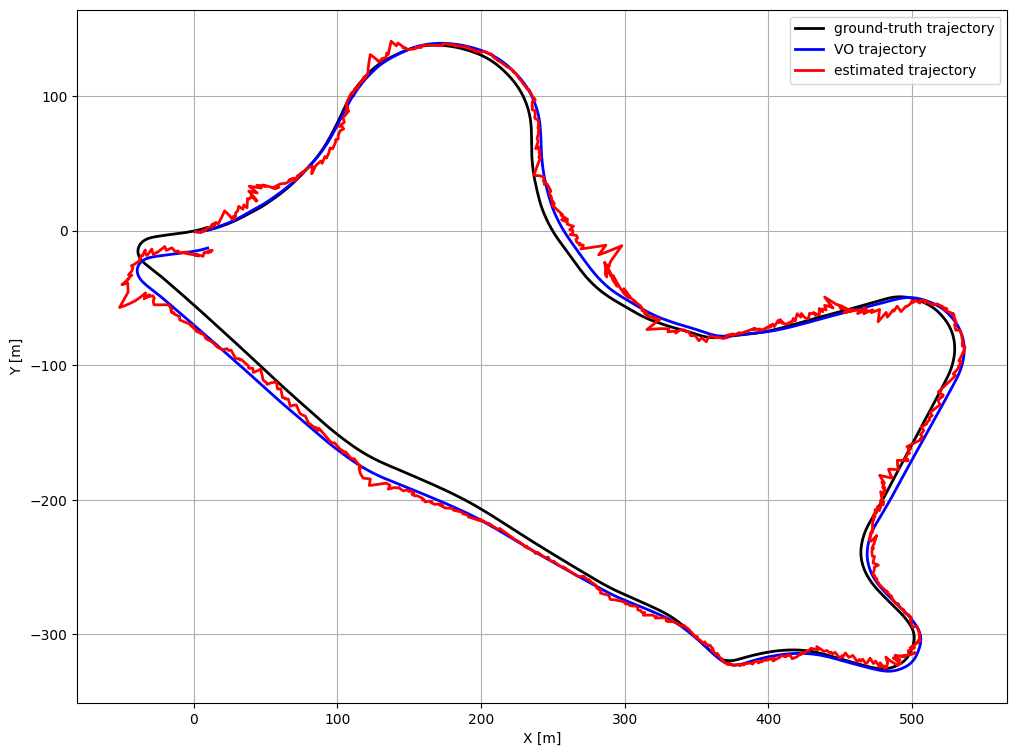

In [7]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

ukf = UKF_wrapper(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_3
)
ukf_error = ukf.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF in Setup1 (IMU + VO)

[UKF] start.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 3012.10it/s]


----- [UKF] Error report for Setup1 (IMU, VO) -----
Mean Absolute Error: 8.417 m
Root Mean Squared Error: 10.848 m
Maximum Error: 44.611 m
---------------------------------------------------



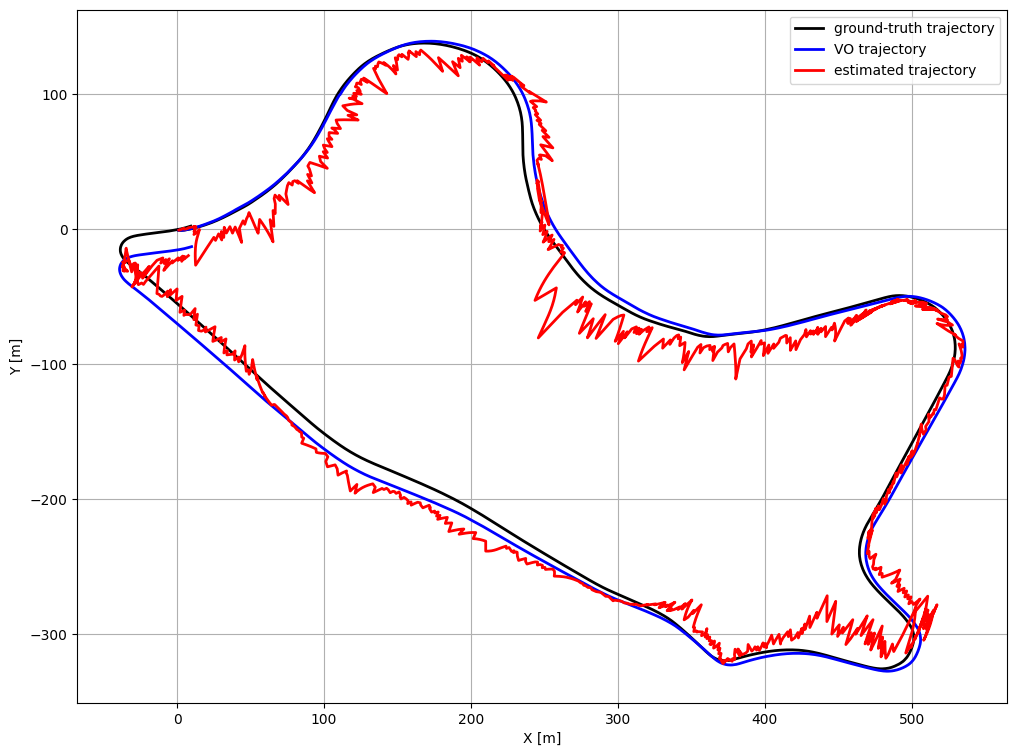

In [8]:
x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_1, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)
ukf = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_1
)
ukf_error = ukf.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## UKF in Setup3 (INS, VO)

[UKF] start.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1590/1590 [00:00<00:00, 13766.21it/s]


----- [UKF] Error report for Setup3 (INS) -----
Mean Absolute Error: 3.913 m
Root Mean Squared Error: 5.534 m
Maximum Error: 15.974 m
-----------------------------------------------



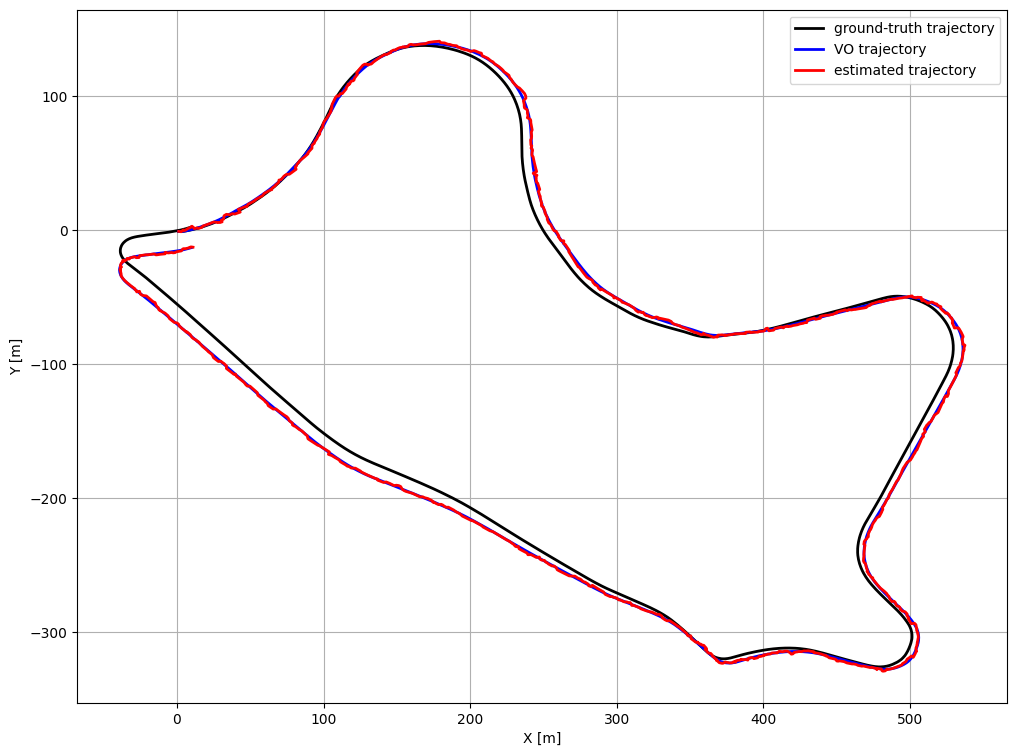

In [9]:

x_setup1, P_setup1, H_setup1, q1, r_vo1, r_gps1 = data.get_initial_data(
    setup=SetupEnum.SETUP_3, 
    filter_type=FilterEnum.UKF,
    noise_type=NoiseTypeEnum.CURRENT
)

alpha_setup1_0 = 1.0
beta_setup1_0 = 2.0
kappa_setup1_0 = 0.0

ukf = UnscentedKalmanFilter(
    x=x_setup1.copy(), 
    P=P_setup1.copy(), 
    H=H_setup1.copy(), 
    q=q1,
    r_vo=r_vo1,
    r_gps=r_gps1,
    alpha=alpha_setup1_0, 
    beta=beta_setup1_0, 
    kappa=kappa_setup1_0,
    setup=SetupEnum.SETUP_3
)
ukf_error = ukf.run(
    data=data, 
    debug_mode=True, 
    show_graph=True,
    measurement_type=MeasurementDataEnum.DROPOUT
)

## Still Work In Progress

In the notebook, named `Madgwick_and_calculated_angular_velocity_comparison.ipynb`, shows that estimated euler angle is almost similar to the angles provided by OXTS. With regard to the forward velocity, our estimation is shows relatively close to the forward velocity provided by OXTS, which is assumed to be obtained by combination of GPS displacement and some kind of filter to smooth the values as shown in the notebook named `gps_displacement_vs_forward_velocity_comparison_test.ipynb`.

Now, we have three setups, Setup1(IMU, VO), Setup2(IMU, VO+GPS), Setup3(INS(forward velocity), VO+GPS) and we agreed upon that Setup3 has a robust estimation than the other setups in terms of overall experiments and the IMU-only filter experiment.

Hence, it is worth trying to implement Setup3, which uses velocity motion model, with estimated forward velocity and z-axis angular velocity to localize the vehicle.

The implementation is shown in the figure below:

<img src="../../../../assets/new-setup.jpg" />

As shown in the figure, there are two filters connected sequentially. The first filter, EKF, introduces Setup1 motion model that uses IMU's linear acceleration and angular velocity to estimate state of the system. In the measurement update step in the EKF, it takes VO to correct position and velocity, which is obtained by displacement / delta time. After correction step, the forward velocity from the EKF and z-axis angular velocity are fed to the second filter to propagate the state based on the velocity motion model in Setup3, then the state is corrected by either VO or VO+GPS.

Until this point, the Unscented Kalman Filter with this implementation and only VO measurement data, supposing GPS-denied environment, outperforms the estimation done by Setup1.

P.S.
In comparison to the Setup3, which uses INS as a control input in prediction step, which already breaks GPS-denied constraints, apparently outperforms the other setups.